# Estrategia de personalización en E-commerce

**Integrantes:** Pascal Salinas, Diego Soto, Matías Soto   |   **Fecha:** 19/05/2026

En esta tarea se resolverá un problema tanto de **regresión** como de **clasificación** sobre un dataset con datos sobre clientes de una empresa de e-commerce, para luego realizar un análisis exhaustivo, el cual se presentará al final de este notebook.

### Descripción del problema
Una empresa de e-commerce, a pesar de haber acumulado grandes volúmenes de datos sobre sus clientes, sigue teniendo una estrategia de marketing homogénea; es decir, todos sus clientes reciben las mismas promociones independientemente de sus preferencias. Es por ello que el área de analítica de esta empresa desea implementar una estrategia de segmentación inteligente, para generar recomendaciones según el comportamiento, el valor y la satisfacción del cliente.

El contexto del problema nos indica que los datos muestran patrones contradictorios, lo cual ha resultado como un problema para la implementación de esta estrategia. Se han recopilado los siguientes datos:

|Variable|Tipo|Unidad|Descripción|
|-|-|-|-|
|`frecuencia`|Numérica|*Compras/Mes*|Número de compras mensuales|
|`gasto`|Numérica|*USD/Compra*|Monto promedio por compra|
|`visitas`|Numérica|*Visitas/Mes*|Número de visitas mensuales al sitio|
|`devoluciones`|Numérica|*Conteo/Mes*|Número de devoluciones mensuales|
|`satisfaccion_cliente`|Numérica|*Escala de 1-5*|Nivel de satisfacción percibida|
|`valor_cliente`|Numérica|*USD/Mes*|Valor total del cliente (`frecuencia` × `gasto`)|
|`cliente_premium`|Categórica|*True/False*|Cliente de alto valor (*percentil > 70*)|

El **objetivo principal del problema de regresión** será predecir el valor de cada cliente a partir de su comportamiento en la plataforma. La variable objetivo será `valor_cliente` y las features a utilizar son `frecuencia`, `gasto`, `visitas`, `devoluciones` y `satisfaccion_cliente`. Esta predicción le sirve a la empresa para estimar cuánto dinero generará un cliente en un mes y en base a ello priorizar recursos, diseñar ofertas personalizadas y proyectar ingresos.

El **objetivo principal del problema de clasificación** será predecir si un cliente pertenece al 30% de mayor valor dentro de la plataforma, es decir, si este es un cliente premium o no. La variable objetivo será `cliente_premium` y las features a utilizar son `frecuencia`, `gasto`, `visitas`, `devoluciones` y `satisfaccion_cliente`. No siempre es posible calcular el valor exacto de un cliente, pero si es posible identificar si pertenece al segmento de más alto valor para la plataforma. Esta clasificación le permite al equipo de marketing activar estrategias diferenciadas, como descuentos exclusivos o atención prioritaria, sin necesidad de conocer el monto exacto del gasto.

## Problema de regresión

Para la resolución de este problema, se utilizó un modelo de regresión lineal `LinearRegression` de la librería **scikit-learn**. Los datos fueron divididos en un 80% para entrenamiento y un 20% para pruebas.

##### Primero, importamos las librerías correspondientes

In [83]:
# imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# --------------- #
# Regresión lineal para el problema de regresión
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [38]:
# extraemos los datos
data = pd.read_csv("dataset.csv", sep=";")
data.head(3)

,frecuencia,gasto,visitas,devoluciones,satisfaccion_cliente,valor_cliente,cliente_premium
0,4.32,30.92,27.89,2.93,1.35,275.00,False
1,3.13,166.09,31.43,1.98,3.58,181.24,False
2,4.10,98.78,64.90,4.48,2.27,419.52,True


##### Ahora, verificamos los valores de $\text{NaN}$

In [39]:
# verificamos los valores NaN, o que no se pueden aceptar
print(data.isnull().sum())

frecuencia              5
gasto                   5
visitas                 5
devoluciones            5
satisfaccion_cliente    5
valor_cliente           5
cliente_premium         5
dtype: int64


##### Como son relativamente pocos valores $\text{NaN}$, podemos limparlos

In [40]:
data = data.dropna()
print(data.isnull().sum()) # volvemos a contar

frecuencia              0
gasto                   0
visitas                 0
devoluciones            0
satisfaccion_cliente    0
valor_cliente           0
cliente_premium         0
dtype: int64


##### Bien, ahora separamos los datos en entrenamiento y testing

In [73]:
# Separamos los datos entonces
X = data[[
    "frecuencia", "gasto"
]]
# "frecuencia", "gasto", "visitas", "devoluciones", "satisfaccion_cliente"
Y = data[
    "valor_cliente"
]
# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

##### Creamos un modelo de $\text{regresión lineal}$ y lo entrenamos

In [75]:
# Creamos el modelo de regresión lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


##### Ahora, podemos realizar predicciones (testear el modelo)

In [76]:
# Hacemos predicciones
y_pred = lin_reg.predict(X_test)

##### Calculamos las métricas de evaluación

In [77]:
mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)
# ---------------------------------------- #
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

MSE: 47383.25118341592
MAE: 160.76850241605365
RMSE: 217.67694224105574
R²: 0.811325346789256


##### Notar que $R^2>0.8$, por ende se tiene un modelo con "Excelente ajuste".

##### Comparamos con la desviación estándar de y_test

In [78]:
# Comparar con la desviación estándar de y_test
std_y_test = np.std(Y_test)
print(f"Desviación estándar de y_test: {std_y_test}")

Desviación estándar de y_test: 501.13605283247614


##### Visualizamos los datos y la línea de regresión

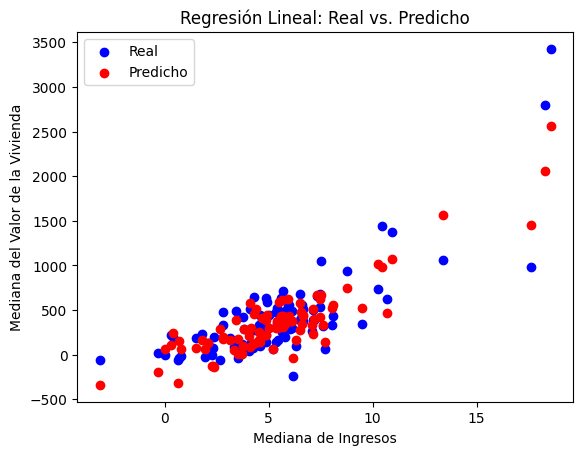

In [79]:
# Visualizar la relación entre valor_cliente y una de las características (frecuencia, gasto, ...)
plt.scatter(X_test['frecuencia'], Y_test, color='blue', label='Real')
plt.scatter(X_test['frecuencia'], y_pred, color='red', label='Predicho')
plt.xlabel('Mediana de Ingresos')
plt.ylabel('Mediana del Valor de la Vivienda')
plt.title('Regresión Lineal: Real vs. Predicho')
plt.legend()
plt.show()

##### Pequeña comparacion de $R^2$ para train y test

In [85]:
r2_train = r2_score(Y_train, lin_reg.predict(X_train))
r2_test  = r2_score(Y_test,  lin_reg.predict(X_test))
print(f"R² train: {r2_train:.4f}")
print(f"R² test:  {r2_test:.4f}")

R² train: 0.7441
R² test:  0.8113


### Análisis
1. ¿Por qué elegir un modelo de **Regresión Lineal** en vez de cualquier otro modelo? 
- Se utilizó un modelo de regresión lineal para predecir "valor_cliente" ya que el caso sugiere que hay una relación lineal con "frecuencia x gasto". Sin embargo esto no se cumple estrictamente para todos los datos, pero si nos permite estimar de buena manera el valor_cliente a cada uno.
- Además, se comparó con un árbol de desición utilizando "DecisionTreeRegressor" y obtuvo $R^2 \approx 0.67$, confirmando que el modelo de regresión lineal es más adecuado para el problema.
2. ¿Por qué se decide entrenar los datos con las features "frecuencia" y "gasto" en vez de todas las demás? 
- Se utilizó frecuencia y gasto solamente ya que, son las dimensiones más significativas para estimar "valor_cliente". Se probó a utilizar todas las dimensiones ( frecuencia, gasto, visitas, devoluciones y satisfaccion_cliente), sin embargo las mejorías fueron despreciables ($<10^{-3}$), por ende se puede ahorrar complejidad disminuyendo las dimensiones a analizar.
3. ¿Por qué no se decidió escalar los datos? 
- No se escaló ya que la regresión lineal es invariante al escalado.
4. ¿El modelo es capaz de generalizar bien o sufre de overfitting?
- El modelo no sufre de overfitting. $R^2$ en test es ligeramente superior al de train, esto nos dice que el modelo generaliza bien los datos que no han sido vistos. Esto puede pasar porque al azar se eligieron datos que eran más representativos.
5. ¿Qué limitaciones tiene este modelo para el negocio?
- Que no para todos los casos se puede hacer una estimación correcta. El modelo asume una relación lineal pero en la práctica no lo es así de estricto, ya que existen clientes que pueden tener una frecuencia alta pero un bajo costo, y viceversa. Para estos dos casos, son perfiles distintos por ende se merecen estrategias de marketing distintas, y esto el modelo no lo captura.

---

## Problema de clasificación

Para la resolución de este problema, se utilizó un modelo de aprendizaje de regresión logística `LogisticRegression` de la librería **scikit-learn**. Al igual que el problema anterior, los datos fueron divididos en un 80% de los mismos para entrenamiento y un 20% para pruebas.

Se usa regresión logística como modelo principal puesto que, para un contexto de negocio, se requiere poder explicar las decisiones del modelo al equipo de marketing. Este modelo le asigna un coeficiente a cada variable, lo que permite identificar directamente qué factores empujan a un cliente hacia el segmento premium y en qué magnitud. Gracias a esto, el modelo de regresión logística es más interpretable que, por ejemplo, un modelo **random forest**.

Dado que este modelo aprende mediante el algoritmo **Gradient Descent**, es necesario aplicar un escalado estándar a los datos previo al entrenamiento. Sin este paso, variables con rangos amplios como `gasto` dominarán artificialmente el cálculo del gradiente por su magnitud y no por su relevancia real.

##### Primero, importamos las librerías específicas para el problema de clasificación.

In [14]:
# Clasificación
from sklearn.linear_model import LogisticRegression

# Métricas de clasificación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Preprocesamiento de los datos
from sklearn.preprocessing import StandardScaler

##### Debido a que los datos ya están limpios gracias al problema de regresión, separamos los datos para la clasificación.

In [15]:
X = data[["frecuencia", "gasto", "visitas", "devoluciones", "satisfaccion_cliente"]]
Y = data["cliente_premium"].map({ True: 1, False: 0 })  # Reemplazamos booleanos a 0 y 1

# Realizamos el split 80/20 para entrenamiento y testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size = 0.2,
    random_state = 42
)

##### A diferencia del modelo de regresión lineal, la regresión logística es sensible a la escala de las variables.

In [16]:
data.head(5)

,frecuencia,gasto,visitas,devoluciones,satisfaccion_cliente,valor_cliente,cliente_premium
0,4.32,30.92,27.89,2.93,1.35,275.00,False
1,3.13,166.09,31.43,1.98,3.58,181.24,False
2,4.10,98.78,64.90,4.48,2.27,419.52,True
3,7.53,50.07,20.90,0.89,0.94,528.88,True
4,3.96,42.75,9.94,2.80,1.01,369.24,False


Se puede observar que variables como `satisfaccion_cliente` tiene una escala de 1-5 mientras que valor cliente (en base a los 5 ejemplos mostrados) toma valores superiores a 500.

##### Las diferentes escalas de los datos pueden afectar al modelo durante gradient descent, ya que el gradiente será mucho más grande para el dato que tenga mayor magnitud independiente de su relevancia real. Para mitigar este problema, escalamos los datos utilizando `StandardScaler` de la librería scikit-learn:

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Una vez escalados los datos, entrenamos el modelo:

In [18]:
log_reg = LogisticRegression(random_state = 42)
log_reg.fit(X_train_scaled, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

##### Una vez entrenado el modelo, podemos hacer predicciones con la porción de testing del dataset:

In [19]:
Y_pred = log_reg.predict(X_test_scaled)

##### Por último, calculamos las métricas de evaluación:

In [20]:
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.7527
Precision: 0.7727
Recall: 0.4857
F1-score: 0.5965


##### Interpretación
- **Accuracy:** El modelo acierta el 75% de los casos. No es la métrica más confiable en este caso puesto que, debido a que el 70% de los datos son de clientes no-premium, un modelo que diga siempre "no premium" ya tendría el 70% de accuracy.
- **Precision:** El modelo acierta el 77% de las veces que predice que un cliente es premium.
- **Recall:** De todos los clientes que realmente son premium, el modelo solo detecta el 48.6%, por lo que se están perdiendo más de la mitad de los clientes valiosos.
- **F1:** El balance resultante entre precision y recall es mediocre, arrastrado principalmente por el recall bajo.

El modelo tiene buena precisión pero mal recall, lo que se puede interpretar como que el modelo solo etiqueta como premium a los clientes cuando está bastante seguro. El problema es que deja escapar a muchos clientes valiosos. Esto puede deberse a los patrones contradictorios en los datos explicados en el contexto.

In [ ]:
# Matriz de confusión
cm = confusion_matrix(Y_test, Y_pred)
print(f"Matriz de confusión:\n{cm}")

Matriz de confusión:
[[53  5]
 [18 17]]


In [ ]:
# Reporte completo
print(f"Reporte completo:\n{classification_report(Y_test, Y_pred)}")

Reporte completo:
              precision    recall  f1-score   support

           0       0.75      0.91      0.82        58
           1       0.77      0.49      0.60        35

    accuracy                           0.75        93
   macro avg       0.76      0.70      0.71        93
weighted avg       0.76      0.75      0.74        93



##### Interpretación
La matriz de confusión se lee de la siguiente manera
||**Predicción: No premium**|**Predicción: Premium**|
|-|-|-|
|**Real: No premium**|53|5|
|**Real: Premium**|18|17|

* El modelo predijo 53 clientes no premium correctamente.
* El modelo predijo 17 clientes premium correctamente.
* El modelo confundió 5 clientes no premium como premium.
* El modelo confundió 18 clientes premium como no premium.

La matriz de confusión nos revela que el modelo tuvo 18 falsos negativos frente a solo 5 falsos positivos.

Además, el resumen general nos indica que la clase 0 (clientes no premium) tiene un recall de 0.91, comparado con el recall 0.49 de la clase 1 (clientes premium). Esto nos indica que el modelo está sesgado hacia predecir no premium, lo cual coincide con lo visto anteriormente. Esto tiene sentido, debido a que en el test, las clases están desbalanceadas (58 clientes no premium vs 35 clientes premium).

                feature  coeficiente
1                 gasto     1.684097
0            frecuencia     1.282457
3          devoluciones    -0.171971
4  satisfaccion_cliente    -0.433289
2               visitas    -0.576671


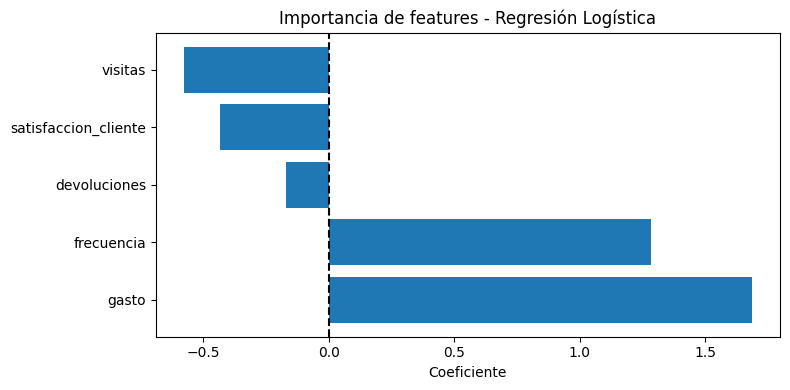

In [ ]:
# Importancia de cada feature según los coeficientes
coeficientes = pd.DataFrame({
    "feature": X.columns,
    "coeficiente": log_reg.coef_[0]
}).sort_values("coeficiente", ascending = False)

print(coeficientes)

# Visualización gráfica
plt.figure(figsize = (8, 4))
plt.barh(coeficientes["feature"], coeficientes["coeficiente"])
plt.axvline(x = 0, color = "black", linestyle = "--")
plt.xlabel("Coeficiente")
plt.title("Importancia de features - Regresión Logística")
plt.tight_layout()
plt.show()

##### Interpretación
El gráfico nos indica que las variables `gasto` y `frecuencia` son los predictores más fuertes de que el cliente sea premium. Esto tiene sentido puesto que, al medir el valor del cliente como `valor_cliente` = `frecuencia` × `gasto` y al `cliente_premium` derivarse de `valor_cliente`, estas variables están correlacionadas de cierta forma con `cliente_premium`.

Además, podemos ver que `devoluciones` tiene un efecto negativo pero pequeño, lo que es de esperar.

Por último, podemos ver que las variables `visitas` y `satisfaccion_cliente` tienen un efecto negativo. Esto se puede interpretar como un cliente que visita mucho pero que compra poco, o que está satisfecho pero no realiza muchas compras (patrones contradictorios advertidos en el contexto del dataset), por lo que el modelo aprendió que estos patrones son de clientes no premium.

### Análisis

El contexto del problema advertía sobre patrones contradictorios, como clientes que compran mucho pero devuelven productos, otros que navegan constantemente sin comprar y otros con alta satisfacción pero bajo gasto. Estos patrones quedaron claramente reflejados en los coeficientes del modelo: `gasto` (1.68) y `frecuencia` (1.28) resultaron ser los predictores más fuertes hacia el segmento premium, mientras que `visitas` (-0.58) y `satisfaccion_cliente` (-0.43) presentaron coeficientes negativos. Estos resultados confirman lo que el contexto anticipaba: navegar sin comprar o estar satisfecho sin gastar no son indicadores de un cliente de alto valor, y el modelo fue capaz de aprender esa diferencia.

En cuanto a los resultados, dado el desbalance de clases en el dataset (58 clientes no-premium y 35 clientes premium en el conjunto de pruebas), la _accuracy_ no es la métrica más representativa, por lo que el _F1-score_ de 0.60 refleja de forma más honesta el rendimiento del modelo. El _F1-score_ es un puntaje mediocre, esto se explica por el bajo _recall_ de 0.49: el modelo es conservador y solo clasifica un cliente como premium cuando tiene alta certeza de ello, lo que se traduce en 18 falsos negativos frente a solo 5 falsos positivos, visibles en la matriz de confusión. En un contexto de e-commerce, esta tendencia implica pérdida de oportunidades de fidelización con clientes valiosos que el modelo no logró identificar.

Como limitaciones principales, se identifican tres aspectos. Primero, el desbalance de clases sesga al modelo a predecir la clase mayoritaria, lo que explica el bajo recall. Segundo, el dataset, al ser pequeño (500 filas), limita la capacidad del modelo de generalizar patrones más complejos. Tercero, dado que `cliente_premium` se deriva directamente de `valor_cliente`, y este a su vez de `frecuencia` y `gasto`, el modelo captura en parte una relación casi trivial entre estas variables, lo que podría estar inflando artificialmente su rendimiento.

Frente a esto último, cabe plantear la pregunta ¿Es realmente necesario implementar un modelo de aprendizaje supervisado para este problema?. `cliente_premium` es una función determinística de variables disponibles en el dataset, una regla de negocio simple (como puede ser decidir si el cliente es premium en base a umbralizar `valor_cliente`) resolvería el problema de forma exacta y con un costo computacional prácticamente nulo. El aprendizaje supervisado cobra verdadero valor cuando los patrones a identificar son complejos y no reducibles a reglas explícitas, lo que no es completamente el caso aquí.

---